# Siamese DNN — standalone holdout + validation evaluation

Loads the trained `dnn_siamese_cor.pt` checkpoint and scores it on the two
out-of-training pair tables:

- **Holdout** (`holdout_*` parquet files): Bainbridge mega-study s2, item-
  disjoint from training but using the same scale families. This stresses the
  model's ability to generalize to new items.
- **Validation** (`validation_*` parquet files): SurveyBot validation study,
  *entirely different scales* (AAID + BFI-10) that the model never saw in
  training. This stresses generalization to new scale formats.

Both passes re-fit the train-pool QuantileTransformer (deterministic from
`SEED`), recompute `global_sim` through the trained autoencoder so the feature
distribution matches training, build a combined item->idx lookup that unions
train + holdout + validation items, and report Pearson r / R² / RMSE / MAE on
the full cross-encoded set.

In [ ]:
# --- 1. Imports & config ---
import os
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Paths ----
# tested models include qwen3-8b-with-instruction, gemini-embedding-2 (task sentence sim), text-embedding-3-large
# intfloat-e5-mistral-7b-instruct (4bit), 
emb_model       = "intfloat-e5-mistral-7b-instruct" # qwen3-8b-with-instruction usually performs best

train_pair_path = f"../../data/raw/item_correlations.parquet"
train_emb_path  = f"../../data/raw/{emb_model}/embeddings_raw.parquet"
# Holdout pair file: full cross-encoded set (item-disjoint + cross-scale combined)
hold_pair_path  = "../../data/raw/holdout_item_correlations.parquet"
hold_emb_path   = f"../../data/raw/{emb_model}/holdout_embeddings_raw.parquet"
# Per-item sentiment files (used to assemble aux features for holdout pairs)
train_path = "../../data/raw/item_list.parquet"
hold_path  = "../../data/raw/holdout_item_list.parquet"
ae_weights_path = "../../models/psychometric_ae_weights.pt"
CKPT_PATH       = "../../models/dnn_siamese_cor.pt"

# ---- Mirror training notebook ----
SEED           = 42
OUTER_VAL_FRAC = 0.2
R_CLIP         = 0.999

ENCODER_DIMS = (512,)
HEAD_DIMS    = (256,)
DROPOUT      = 0.163
USE_SKIP     = False

# ---- Eval only ----
EVAL_CHUNK = 8192

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(SEED); np.random.seed(SEED)

Device: cuda:0


In [10]:
# --- 2. Load training embeddings + pair table ---
# Both are needed: embeddings to build the lookup table the model reads from,
# pair table to re-derive the same item_disjoint split the training notebook
# used (so we can re-fit the scaler on the same training pool).

emb_df   = pl.read_parquet(train_emb_path)
emb_cols = [c for c in emb_df.columns if c.startswith("emb")]
EMB_DIM  = len(emb_cols)
print(f"Training embeddings: {emb_df.shape}  emb_dim={EMB_DIM}")

item_to_idx = {name: i for i, name in enumerate(emb_df["item"].to_list())}
ITEM_EMB = torch.tensor(
    emb_df.select(emb_cols).to_numpy(), dtype=torch.float32
).to(device)
print(f"ITEM_EMB on device: {tuple(ITEM_EMB.shape)}")

dat = pl.read_parquet(train_pair_path).filter(
    (pl.col("r").is_not_null()) & (pl.col("r") != 1)
)

def add_global_sim(df, emb, name_to_idx, chunk=50_000):
    known = pl.Series("item", list(name_to_idx.keys())).implode()
    df = df.filter(pl.col("Parameter1").is_in(known) & pl.col("Parameter2").is_in(known))
    i1 = np.fromiter((name_to_idx[p] for p in df["Parameter1"].to_list()), np.int64)
    i2 = np.fromiter((name_to_idx[p] for p in df["Parameter2"].to_list()), np.int64)

    En  = torch.nn.functional.normalize(emb, dim=1)        # unit rows, computed once
    out = np.empty(len(i1), dtype=np.float32)
    with torch.no_grad():
        for s in range(0, len(i1), chunk):
            sl = slice(s, s + chunk)
            a = En[torch.as_tensor(i1[sl], device=En.device)]
            b = En[torch.as_tensor(i2[sl], device=En.device)]
            out[sl] = (a * b).sum(dim=1).cpu().numpy()      # cosine = dot of unit vecs
    return df.with_columns(pl.Series("global_sim", out))

dat = add_global_sim(dat, ITEM_EMB, item_to_idx)
print(f"Pair rows (with embeddings): {dat.height:,}")

Training embeddings: (3127, 4097)  emb_dim=4096
ITEM_EMB on device: (3127, 4096)
Pair rows (with embeddings): 452,026


In [11]:
# --- 3. Re-do item_disjoint split, fit preprocessor on training pool ---
# Identical seed + logic to the training notebook so the QuantileTransformer
# learns from exactly the same rows.

items_all = (
    pl.concat([
        dat.select(pl.col("Parameter1").alias("item")),
        dat.select(pl.col("Parameter2").alias("item")),
    ]).unique().to_series().sample(fraction=1.0, seed=SEED)
)
split_idx   = int(len(items_all) * (1 - OUTER_VAL_FRAC))
train_items = items_all.slice(0, split_idx).implode()
train_df = dat.filter(
    pl.col("Parameter1").is_in(train_items) & pl.col("Parameter2").is_in(train_items)
)
print(f"Reconstructed training pool: {train_df.height:,} pairs")

scaler  = QuantileTransformer(
    output_distribution="normal", n_quantiles=1000,
    subsample=200_000, random_state=SEED,
).fit(train_df.select(pl.col('global_sim')).to_numpy())

AUX_DIM = scaler.transform(train_df.select(pl.col('global_sim')).head(1).to_numpy()).shape[1]
print(f"AUX_DIM (numeric) = {AUX_DIM}")

Reconstructed training pool: 290,472 pairs
AUX_DIM (numeric) = 1


In [12]:
# --- 4. Model architecture + load checkpoint ---
# Must mirror the training notebook bit-for-bit.

class SiameseEncoder(nn.Module):
    def __init__(self, emb_dim, encoder_dims, dropout):
        super().__init__()
        layers, prev = [], emb_dim
        for h in encoder_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        self.net = nn.Sequential(*layers)
        self.out_dim = prev
    def forward(self, x):
        return self.net(x)


class SiameseDNN(nn.Module):
    def __init__(self, emb_dim, aux_dim, encoder_dims, head_dims, dropout, use_skip):
        super().__init__()
        self.encoder = SiameseEncoder(emb_dim, encoder_dims, dropout)
        e = self.encoder.out_dim
        head_in = 4 * e + aux_dim
        layers, prev = [], head_in
        for h in head_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        self.head = nn.Sequential(*layers)
        self.out  = nn.Linear(prev, 1)
        self.use_skip = use_skip
        if use_skip:
            self.aux_skip = nn.Linear(aux_dim, 1)
    def forward(self, e1, e2, aux):
        h1 = self.encoder(e1)
        h2 = self.encoder(e2)
        inter = torch.cat([h1, h2, h1 * h2, (h1 - h2).abs()], dim=-1)
        x = torch.cat([inter, aux], dim=-1)
        z = self.out(self.head(x)).squeeze(-1)
        if self.use_skip:
            z = z + self.aux_skip(aux).squeeze(-1)
        return z   # Fisher-z space


model = SiameseDNN(
    emb_dim=EMB_DIM, aux_dim=AUX_DIM,
    encoder_dims=ENCODER_DIMS, head_dims=HEAD_DIMS,
    dropout=DROPOUT, use_skip=USE_SKIP,
).to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f"Loaded checkpoint from {CKPT_PATH}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Loaded checkpoint from ../../models/dnn_siamese_cor.pt
Trainable params: 2,624,257


In [13]:
# --- 5. Holdout evaluation (full cross-encoded set) ---
# 1) Load the pair file.
# 2) Build a COMBINED embedding lookup (train items + holdout-only items).
# 3) Drop pairs referencing unknown items.
# 4) Join sentiment from both train and holdout sentiment tables.
# 5) Recompute global_sim through the trained autoencoder.
# 6) Featurize through the train-fitted scaler.
# 7) Score in chunks and report metrics.

# ---- 1. Pair file ----
hold_df = pl.read_parquet(hold_pair_path).filter(
    (pl.col("r").is_not_null()) & (pl.col("r") != 1)
)
print(f"Holdout pair rows on disk: {hold_df.height:,}")

# ---- 2. Combined embedding lookup ----
hold_emb_df   = pl.read_parquet(hold_emb_path)
hold_emb_cols = [c for c in hold_emb_df.columns if c.startswith("emb")]
assert len(hold_emb_cols) == EMB_DIM, "Holdout embedding dim doesn't match training dim"

combined_item_to_idx = dict(item_to_idx)
new_local_rows, new_names = [], []
for local_row, name in enumerate(hold_emb_df["item"].to_list()):
    if name not in combined_item_to_idx:
        combined_item_to_idx[name] = len(item_to_idx) + len(new_local_rows)
        new_local_rows.append(local_row)
        new_names.append(name)

if new_local_rows:
    hold_emb_np  = hold_emb_df.select(hold_emb_cols).to_numpy()[new_local_rows]
    HOLD_EMB_NEW = torch.tensor(hold_emb_np, dtype=torch.float32).to(device)
    COMBINED_EMB = torch.cat([ITEM_EMB, HOLD_EMB_NEW], dim=0)
else:
    COMBINED_EMB = ITEM_EMB
print(f"Combined embedding lookup: {len(item_to_idx):,} train + {len(new_names):,} new holdout = {COMBINED_EMB.shape[0]:,} items")

# ---- 3. Drop unknown items (should be 0 here) ----
known_all = pl.Series("item", list(combined_item_to_idx.keys())).implode()
pre_n = hold_df.height
hold_df = hold_df.filter(
    pl.col("Parameter1").is_in(known_all) & pl.col("Parameter2").is_in(known_all)
)
print(f"After item-lookup filter: {hold_df.height:,} pairs (dropped {pre_n - hold_df.height:,})")

# ---- 4. global_sim = raw cosine over all embedding dims (matches training) ----
hold_df = add_global_sim(hold_df, COMBINED_EMB, combined_item_to_idx)

idx1 = np.fromiter((combined_item_to_idx[p] for p in hold_df["Parameter1"].to_list()), np.int64)
idx2 = np.fromiter((combined_item_to_idx[p] for p in hold_df["Parameter2"].to_list()), np.int64)

# ---- 5. Featurize ----
aux = scaler.transform(hold_df.select(pl.col('global_sim')).to_numpy())
y_h     = hold_df.select("r").to_numpy().flatten().astype(np.float32)

idx1_t = torch.tensor(idx1, dtype=torch.long, device=device)
idx2_t = torch.tensor(idx2, dtype=torch.long, device=device)
aux_t  = torch.tensor(aux,  dtype=torch.float32, device=device)

# ---- 6. Score + report ----
chunks = []
with torch.no_grad():
    for s in range(0, idx1_t.shape[0], EVAL_CHUNK):
        e1 = COMBINED_EMB[idx1_t[s:s+EVAL_CHUNK]]
        e2 = COMBINED_EMB[idx2_t[s:s+EVAL_CHUNK]]
        ax_ = aux_t[s:s+EVAL_CHUNK]
        chunks.append(torch.tanh(model(e1, e2, ax_)).cpu().numpy())
h_preds = np.concatenate(chunks)

corr_h, _ = pearsonr(y_h, h_preds)
rmse_h    = np.sqrt(mean_squared_error(y_h, h_preds))
r2_h      = r2_score(y_h, h_preds)
mae_h     = mean_absolute_error(y_h, h_preds)

print("\n=== SIAMESE DNN HOLDOUT EVALUATION ===")
print(f"N pairs:    {len(y_h):,}")
print(f"Pearson r:  {corr_h:.4f}")
print(f"R-squared:  {r2_h:.4f}")
print(f"RMSE:       {rmse_h:.4f}")
print(f"MAE:        {mae_h:.4f}")

Holdout pair rows on disk: 87,153
Combined embedding lookup: 3,127 train + 292 new holdout = 3,419 items
After item-lookup filter: 87,153 pairs (dropped 0)

=== SIAMESE DNN HOLDOUT EVALUATION ===
N pairs:    87,153
Pearson r:  0.8647
R-squared:  0.7052
RMSE:       0.0884
MAE:        0.0687


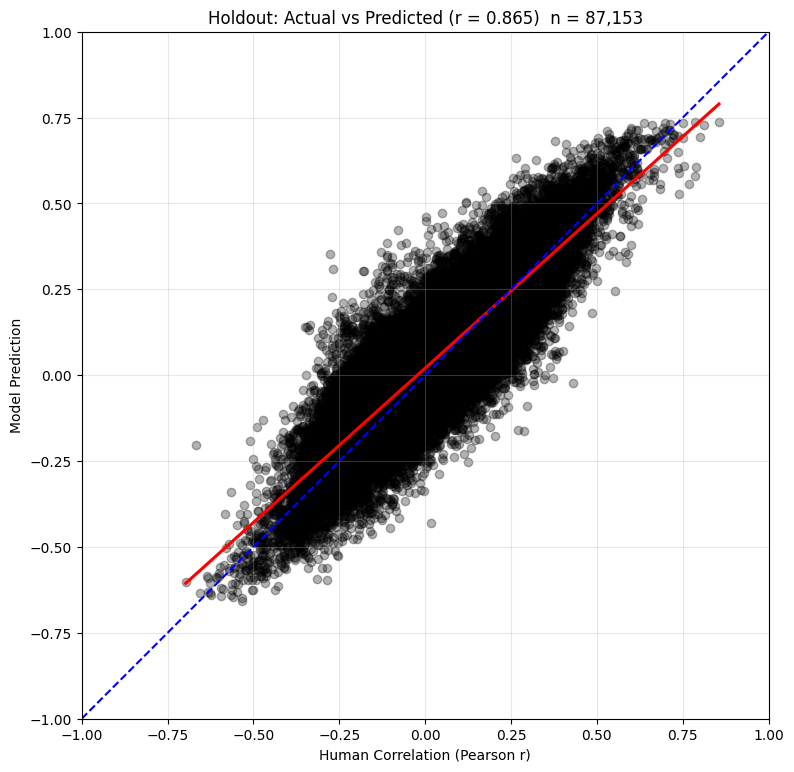

In [14]:
# --- 7. Holdout scatter ---
fig, ax = plt.subplots(figsize=(8, 8))
sns.regplot(
    x=y_h, y=h_preds, ax=ax,
    scatter_kws={"alpha": 0.3, "color": "black"},
    line_kws={"color": "red"},
)
ax.plot([-1, 1], [-1, 1], color="blue", linestyle="--")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Holdout: Actual vs Predicted (r = {corr_h:.3f})  n = {len(y_h):,}")
ax.set_xlabel("Human Correlation (Pearson r)")
ax.set_ylabel("Model Prediction")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Validation evaluation

Same procedure as the holdout pass above, but pointed at the `validation_*`
parquet files (SurveyBot study). These are *entirely separate scales* (AAID +
BFI-10) - a stricter generalization test than the holdout. The combined
embedding lookup is extended once more so a single forward pass scores
train + holdout + validation items consistently.


In [15]:
# --- 8. Validation evaluation ---
# 1) Load the raw validation pair file.
# 2) Extend the embedding lookup with validation-only items.
# 3) Drop pairs referencing unknown items.
# 4) Compute global_sim as raw cosine over all 4096 dims.
# 5) Apply the train-fitted scaler and score in chunks.

val_pair_path = "../../data/raw/validation_item_correlations.parquet"
val_emb_path  = f"../../data/raw/{emb_model}/validation_embeddings_raw.parquet"

# ---- 1. Pair file ----
val_df = pl.read_parquet(val_pair_path).filter(
    (pl.col("r").is_not_null()) & (pl.col("r") != 1)
)
print(f"Validation pair rows on disk: {val_df.height:,}")

# ---- 2. Extend the combined embedding lookup with validation-only items ----
val_emb_df   = pl.read_parquet(val_emb_path)
val_emb_cols = [c for c in val_emb_df.columns if c.startswith("emb")]
assert len(val_emb_cols) == EMB_DIM, "Validation embedding dim doesn't match training dim"

val_item_to_idx = dict(combined_item_to_idx)
new_local_rows_v, new_names_v = [], []
for local_row, name in enumerate(val_emb_df["item"].to_list()):
    if name not in val_item_to_idx:
        val_item_to_idx[name] = COMBINED_EMB.shape[0] + len(new_local_rows_v)
        new_local_rows_v.append(local_row)
        new_names_v.append(name)

if new_local_rows_v:
    val_emb_np       = val_emb_df.select(val_emb_cols).to_numpy()[new_local_rows_v]
    VAL_EMB_NEW      = torch.tensor(val_emb_np, dtype=torch.float32).to(device)
    VAL_COMBINED_EMB = torch.cat([COMBINED_EMB, VAL_EMB_NEW], dim=0)
else:
    VAL_COMBINED_EMB = COMBINED_EMB
print(f"Validation embedding lookup: {COMBINED_EMB.shape[0]:,} prior + "
      f"{len(new_names_v):,} new validation = {VAL_COMBINED_EMB.shape[0]:,} items")

# ---- 3. Drop unknown items (should be 0) ----
known_all_v = pl.Series("item", list(val_item_to_idx.keys())).implode()
pre_n = val_df.height
val_df = val_df.filter(
    pl.col("Parameter1").is_in(known_all_v) & pl.col("Parameter2").is_in(known_all_v)
)
print(f"After item-lookup filter: {val_df.height:,} pairs (dropped {pre_n - val_df.height:,})")

# ---- 4. global_sim = raw cosine over all 4096 dims (matches training) ----
val_df = add_global_sim(val_df, VAL_COMBINED_EMB, val_item_to_idx)
idx1_v = np.fromiter((val_item_to_idx[p] for p in val_df["Parameter1"].to_list()), np.int64)
idx2_v = np.fromiter((val_item_to_idx[p] for p in val_df["Parameter2"].to_list()), np.int64)

# ---- 5. Featurize through the train-fitted scaler ----
aux_v = scaler.transform(val_df.select(pl.col('global_sim')).to_numpy())
y_v   = val_df.select("r").to_numpy().flatten().astype(np.float32)

idx1_vt = torch.tensor(idx1_v, dtype=torch.long, device=device)
idx2_vt = torch.tensor(idx2_v, dtype=torch.long, device=device)
aux_vt  = torch.tensor(aux_v,  dtype=torch.float32, device=device)

# ---- 6. Score + report ----
chunks_v = []
model.eval()
with torch.no_grad():
    for s in range(0, idx1_vt.shape[0], EVAL_CHUNK):
        e1  = VAL_COMBINED_EMB[idx1_vt[s:s+EVAL_CHUNK]]
        e2  = VAL_COMBINED_EMB[idx2_vt[s:s+EVAL_CHUNK]]
        ax_ = aux_vt[s:s+EVAL_CHUNK]
        chunks_v.append(torch.tanh(model(e1, e2, ax_)).cpu().numpy())
v_preds = np.concatenate(chunks_v)

corr_v, _ = pearsonr(y_v, v_preds)
rmse_v    = np.sqrt(mean_squared_error(y_v, v_preds))
r2_v      = r2_score(y_v, v_preds)
mae_v     = mean_absolute_error(y_v, v_preds)

print("\n=== SIAMESE DNN VALIDATION EVALUATION ===")
print(f"N pairs:    {len(y_v):,}")
print(f"Pearson r:  {corr_v:.4f}")
print(f"R-squared:  {r2_v:.4f}")
print(f"RMSE:       {rmse_v:.4f}")
print(f"MAE:        {mae_v:.4f}")

Validation pair rows on disk: 34,191
Validation embedding lookup: 3,419 prior + 262 new validation = 3,681 items
After item-lookup filter: 34,191 pairs (dropped 0)

=== SIAMESE DNN VALIDATION EVALUATION ===
N pairs:    34,191
Pearson r:  0.7538
R-squared:  0.5655
RMSE:       0.1349
MAE:        0.1055


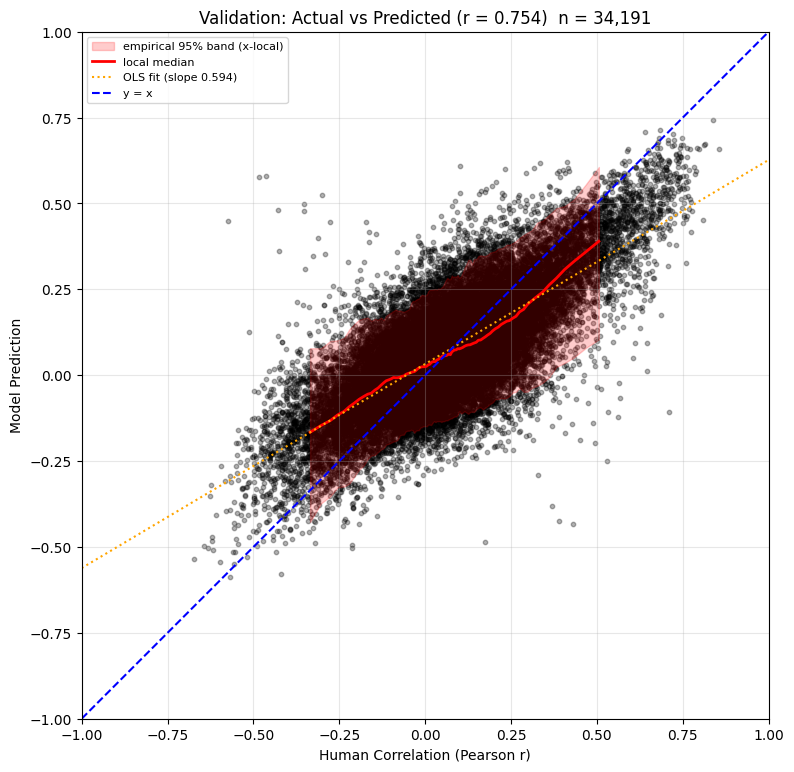

In [16]:
# --- 9. Validation scatter (smooth x-local 95% band) ---
x = np.asarray(y_v,     dtype=float)
y = np.asarray(v_preds, dtype=float)
n = len(x)

# Sliding window over x-sorted points -> smooth band that tightens/widens with density
order  = np.argsort(x)
xs, ys = x[order], y[order]
W      = max(200, int(0.05 * n))     # window size (5% of points); bigger = smoother
step   = max(1, W // 5)

gx, glo, gmed, ghi = [], [], [], []
for c in range(W // 2, n - W // 2, step):
    sl = slice(c - W // 2, c + W // 2)
    gx.append(xs[c])
    glo.append(np.quantile(ys[sl], 0.025))
    gmed.append(np.median(ys[sl]))
    ghi.append(np.quantile(ys[sl], 0.975))
gx, glo, gmed, ghi = map(np.array, (gx, glo, gmed, ghi))

b1, b0 = np.polyfit(x, y, 1)
xg = np.linspace(-1, 1, 200)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x, y, alpha=0.3, color="black", s=10)
ax.fill_between(gx, glo, ghi, color="red", alpha=0.2, label="empirical 95% band (x-local)")
ax.plot(gx, gmed, color="red", lw=2, label="local median")
ax.plot(xg, b0 + b1 * xg, color="orange", lw=1.5, ls=":", label=f"OLS fit (slope {b1:.3f})")
ax.plot([-1, 1], [-1, 1], color="blue", linestyle="--", label="y = x")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Validation: Actual vs Predicted (r = {corr_v:.3f})  n = {n:,}")
ax.set_xlabel("Human Correlation (Pearson r)")
ax.set_ylabel("Model Prediction")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()